# Más allá del TLC: Extreme Value Theory (EVT)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pedro9olivares/Bourbaki/blob/main/Matematicas-para-la-Ciencia-de-Datos/Modulo-I-Probabilidad-y-Estad%C3%ADstica/Semana_3_Convergencia_LGN_y_TLC/Extreme_Value_Theory.ipynb)

*"In cauda venenum"* (Extreme Value Theory: An Introduction, Laurens de Haan)

La Kurtosis puede ser útil, pero está limitada.

**Algunas aplicaciones de EVT**
1. Límite de la esperanza de vida humana  
2. Récords máximos en deportes  
3. Altura de diques  
4. Rascacielos  
5. Gestión de riesgos


## Teoría

Como ejemplo, en finanzas, cuando queremos estudiar el impacto de pérdidas grandes y su probabilidad de ocurrencia, la distribución normal falla porque estos eventos son raros y quedan ignorados. 

La **Teoría de Valores Extremos (EVT)** permite modelar por separado los eventos extremos, destacando su comportamiento y respondiendo preguntas de interés sobre estos casos poco frecuentes.


Según la **Teoría de Valores Extremos (EVT)**, para que un conjunto de datos pueda analizarse como datos extremos, el máximo muestral debe tener una **distribución límite**.  

Es decir, si $ X_1, \dots, X_n$ es una muestra aleatoria de una función de distribución $F$, existen sucesiones $a_n > 0$ y $b_n \in \mathbb{R}$ tales que

$$
\frac{\max(X_1, \dots, X_n) - b_n}{a_n}
$$

tiene una **distribución límite no degenerada** cuando $ n \to \infty$. 

Se sabe que las distribuciones límite no degeneradas pertenecen a la familia Generalized Extreme Value (GEV):

$$
G_\gamma(x) =
\begin{cases}
\exp\!\left(-(1+\gamma x)^{-1/\gamma}\right), & \gamma \neq 0, \\
\exp\!\left(-e^{-x}\right), & \gamma = 0.
\end{cases}
$$

Y el valor del parámetro $\gamma$, también conocido como *Extreme Value Index*, nos da información de las colas:
- $\gamma$ positiva indica una distribución con extremo infinito, lo que significa que se trata de una distribución de cola pesada.  
- $\gamma$ cero significa que el extremo de la distribución es infinito, lo que corresponde a una distribución de cola ligera.  
- $\gamma$ negativa se refiere a una distribución con extremo finito, lo que indica una distribución de cola corta.


## Práctica

Por lo general, el análisis de extremos comienza con un conjunto de datos grande y luego se reduce para analizar solo las observaciones extremas. Existen dos métodos principales para seleccionar estas observaciones:  

- **Máximos por bloques**: divide los datos en bloques y toma el máximo de cada bloque. Requiere un conjunto de datos muy grande para tener suficientes bloques.  
- **Peaks over Treshold (POT)**: enfoque más moderno, considera todas las observaciones por encima de un umbral alto especificado. Elegir el umbral es crítico.


Después de seleccionar los extremos mediante *block maxima* o POT, estimamos el parámetro $\gamma$ (EVI) sobre ese conjunto. La estimación se realiza, por ejemplo, con el **Hill estimator** en POT o mediante **máxima verosimilitud** en block maxima.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis

In [2]:
mx_data = pd.read_csv("datos/MXvideos.csv", encoding='latin1')
uk_data = pd.read_csv("datos/GBvideos.csv", encoding='latin1')
jp_data = pd.read_csv("datos/JPvideos.csv", encoding='latin1')

In [3]:
mx_data.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,SbOwzAl9ZfQ,17.14.11,CapÃ­tulo 12 | MasterChef 2017,MasterChef 2017,24,2017-11-13T06:06:22.000Z,"MasterChef Junior 2017|""TV Azteca""|""recetas""|""...",310130,4182,361,1836,https://i.ytimg.com/vi/SbOwzAl9ZfQ/default.jpg,False,False,False,Disfruta la presencia del Chef Torreblanca en ...
1,klOV6Xh-DnI,17.14.11,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,Micky Contreras Martinez,22,2017-11-13T05:11:58.000Z,La Voz Mexico 7,104972,271,174,369,https://i.ytimg.com/vi/klOV6Xh-DnI/default.jpg,False,False,False,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...
2,6L2ZF7Qzsbk,17.14.11,LOUIS CKAGÃ - EL PULSO DE LA REPÃBLICA,El Pulso De La RepÃºblica,25,2017-11-13T17:00:02.000Z,"Chumel Torres|""El Pulso de la Republica""|""noti...",136064,10105,266,607,https://i.ytimg.com/vi/6L2ZF7Qzsbk/default.jpg,False,False,False,La canciÃ³n del principio se llama âEste esp...
3,hcY52MFWMDM,17.14.11,Sismo de 6.7 sacude Costa Rica 12 Noviembre 2017,Casanare,25,2017-11-13T03:47:10.000Z,"temblor|""costa rica""|""sismo en costa rica""",96153,378,171,208,https://i.ytimg.com/vi/hcY52MFWMDM/default.jpg,False,False,False,El video es de un Walmart en el pais centroame...
4,_OXDcGPVAa4,17.14.11,DOG HACKS | MUSAS LESSLIE LOS POLINESIOS,Musas,26,2017-11-13T19:17:48.000Z,"MUSAS|""lesslie""|""karen""|""hacks""|""perros""|""dogs...",499965,57781,681,7428,https://i.ytimg.com/vi/_OXDcGPVAa4/default.jpg,False,False,False,MI HERMANO NARRA MI RUTINA DE MAQUILLAJE\nhttp...


In [4]:
views_data = {
    "MX": mx_data["views"],
    "UK": uk_data["views"],
    "JP": jp_data["views"]
}

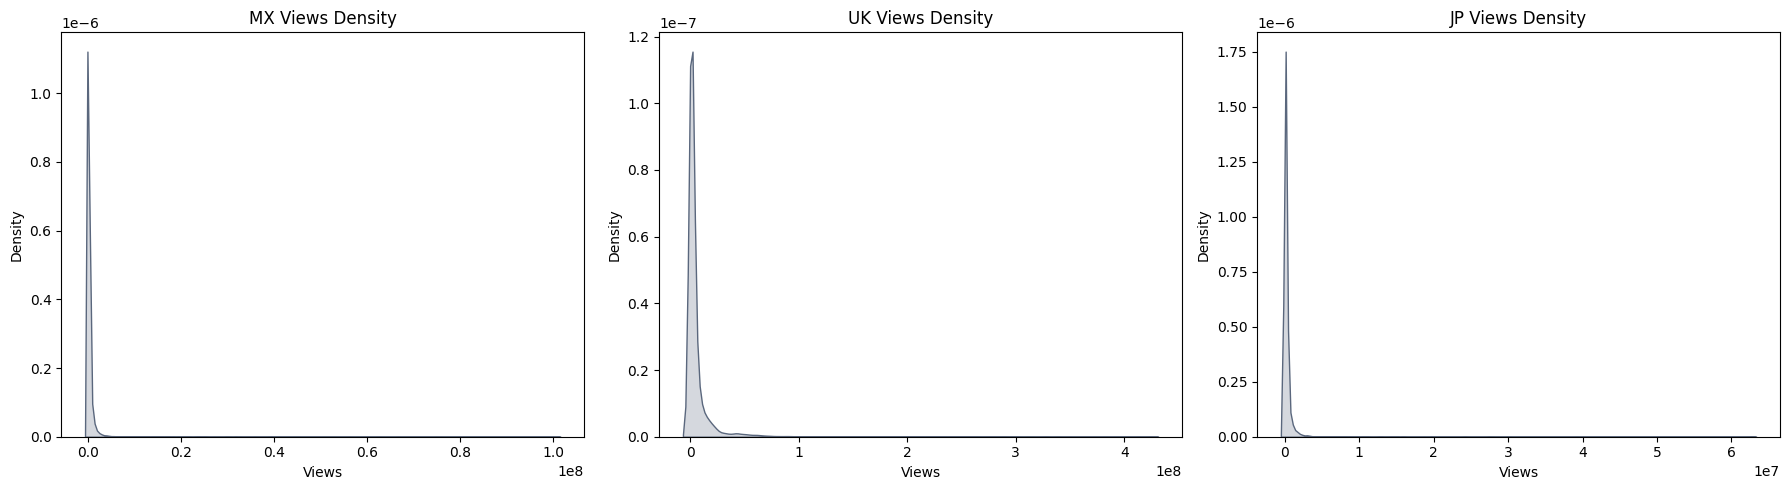

In [5]:
# Veamos las densidades
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (region, views) in zip(axes, views_data.items()):
    sns.kdeplot(views, ax=ax, fill=True, color='#5A677D') # Kernel Density Estimate: un histograma suavizada
    ax.set_title(f"{region} Views Density")
    ax.set_xlabel("Views")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [8]:
# Revisemos kurtosis
for region, views in views_data.items():
    k = kurtosis(views, fisher=True, bias=False)  # Fisher=True gives excess kurtosis
    print(f"{region} Views Kurtosis: {k:.3f}")

MX Views Kurtosis: 812.914
UK Views Kurtosis: 115.412
JP Views Kurtosis: 1182.716


In [11]:
def hill_estimator(exceedances):
    """
    Hill estimator for the extreme value index (EVI)
    exceedances: array of values above threshold
    """
    n = len(exceedances)
    sorted_exc = np.sort(exceedances)[::-1]  # descending order

    # Standard Hill formula
    logs = np.log(sorted_exc / sorted_exc[-1])  # log(x_i / x_k)

    gamma = np.mean(logs)
    
    return gamma

evi_results = {}

for region, views in views_data.items():
    # Choose threshold (99th percentile)
    threshold = np.percentile(views, 99)
    
    # Get exceedances above threshold
    exceedances = views[views > threshold]
    
    # Calculate EVI using Hill estimator
    gamma = hill_estimator(exceedances)
    evi_results[region] = gamma

for region, gamma in evi_results.items():
    print(f"{region} EVI (POT): {gamma:.4f}")


MX EVI (POT): 0.7627
UK EVI (POT): 0.5333
JP EVI (POT): 0.6925


In [12]:
# Expected shortfall
es_results = {}

for region, views in views_data.items():
    # Calculate 99th percentile (VaR)
    var_99 = np.percentile(views, 99)
    
    # Get exceedances above 99th percentile
    exceedances = views[views > var_99]
    
    # Calculate Expected Shortfall (average of exceedances)
    es = exceedances.mean()
    es_results[region] = es

for region, es in es_results.items():
    print(f"{region} Expected Shortfall (99th percentile): {es:.2f}")

MX Expected Shortfall (99th percentile): 12109331.14
UK Expected Shortfall (99th percentile): 151374326.72
JP Expected Shortfall (99th percentile): 8237904.58


In [13]:
# Initialize a dictionary to store all results
results = {}

for region, views in views_data.items():
    results[region] = {
        "Kurtosis": kurtosis(views, fisher=True, bias=False),
        "EVI (POT)": evi_results.get(region, None),
        "Expected Shortfall (99%)": es_results.get(region, None)
    }

# Convert to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df[["Kurtosis", "EVI (POT)", "Expected Shortfall (99%)"]]

# Display
print(results_df)

       Kurtosis  EVI (POT)  Expected Shortfall (99%)
MX   812.914440   0.762650              1.210933e+07
UK   115.411991   0.533288              1.513743e+08
JP  1182.715625   0.692482              8.237905e+06


Los tres países presentan distribuciones con **colas pesadas**, es decir, videos con cantidades de vistas/interacciones extremadamente grandes aparecen mucho más frecuentemente de lo que predeciría una distribución normal.

- **Japón (JP)** tiene la mayor curtosis (~1183), indicando la presencia de videos extremadamente virales y valores muy alejados del promedio. Su EVI (~0.69) también confirma una cola pesada importante.

- **México (MX)** muestra igualmente una curtosis muy alta (~813) y el mayor EVI (~0.76), sugiriendo que los fenómenos virales extremos son especialmente frecuentes y persistentes.

- **Reino Unido (UK)** tiene menor curtosis (~115) y un EVI más moderado (~0.53), por lo que sus extremos son relativamente menos severos. Sin embargo, su *Expected Shortfall* al 99% es el más alto, lo que indica que, cuando ocurren eventos extremos, el volumen esperado de vistas/interacciones puede ser muchísimo mayor en términos absolutos (vistas).

En conjunto, MX y JP muestran comportamientos más extremos estadísticamente, mientras que UK concentra los mayores valores absolutos en escenarios virales extremos.

**En resumen:** La curtosis indica la presencia de valores atípicos en toda la distribución, mientras que el índice de valor extremo (EVI) mide específicamente qué tan pesada es la cola de los eventos extremos.


Datos: https://www.kaggle.com/datasets/datasnaek/youtube-new